## Step 1: Data Preparation & Exploration (EDA)

Dataset Shape: (908, 13)

Missing Values:
 age          0
sex          0
cp           0
trestbps     0
chol         0
fbs          0
restecg      0
thalch       0
exang        0
oldpeak     62
slope        0
thal         0
num          0
dtype: int64

Data Types:
 age           int64
sex          object
cp           object
trestbps      int64
chol          int64
fbs            bool
restecg      object
thalch        int64
exang        object
oldpeak     float64
slope        object
thal         object
num           int64
dtype: object


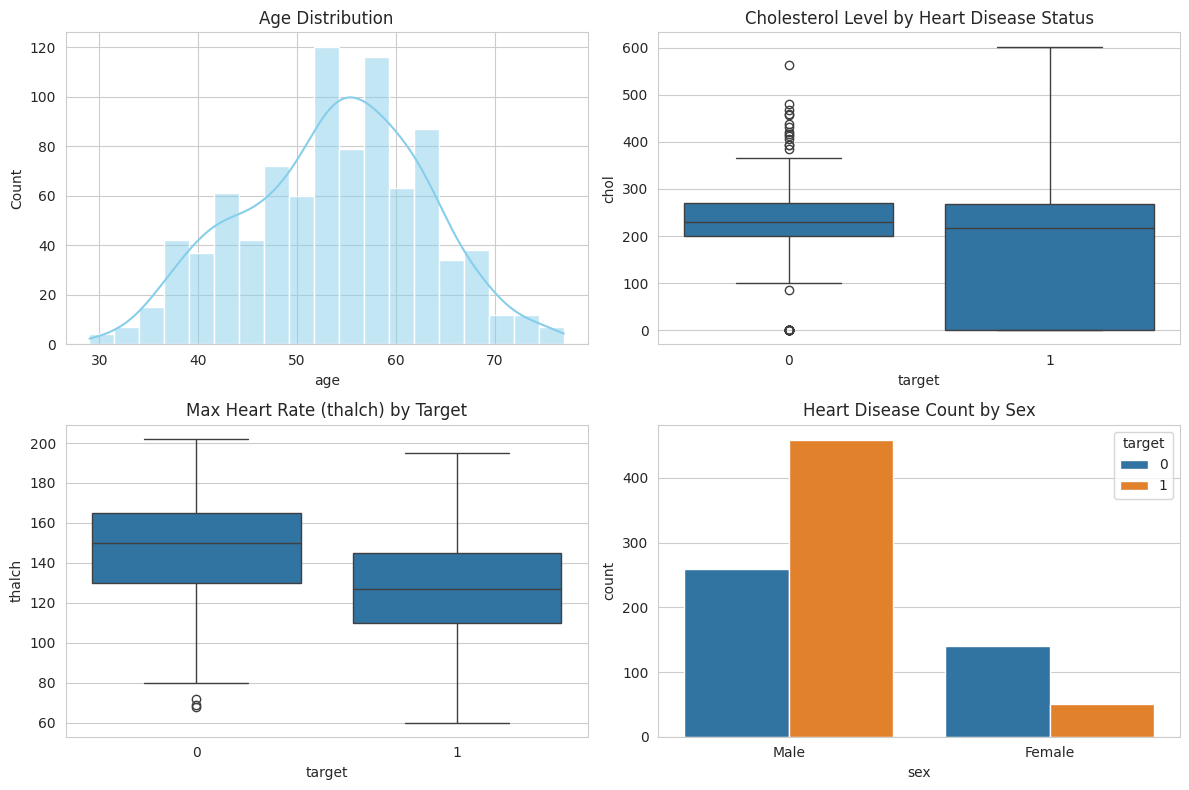

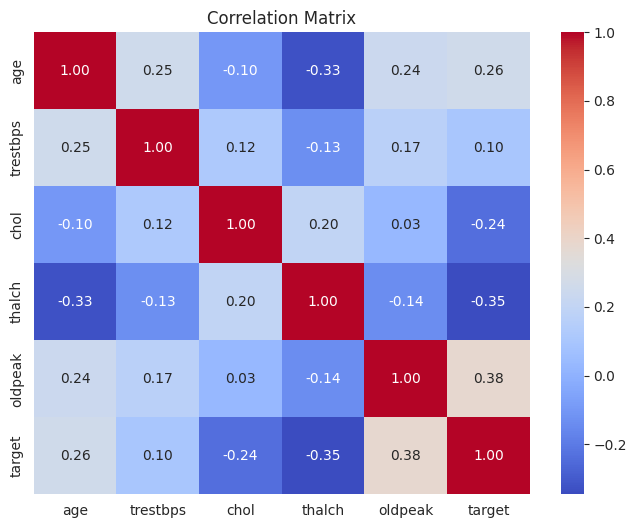

In [47]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# 1. Load the dataset
file_path = "heart_disease.xlsx"
df = pd.read_excel(file_path, sheet_name="Heart_disease")

# 2. Basic Inspection
print("Dataset Shape:", df.shape)
print("\nMissing Values:\n", df.isnull().sum())
print("\nData Types:\n", df.dtypes)

# Target variable processing (convert target 'num' to binary: 0 = No Disease, 1 = Heart Disease)
df["target"] = (df["num"] > 0).astype(int)
df.drop(columns=["num"], inplace=True)

# 3. Visualizations
plt.figure(figsize=(12, 8))

# Numeric Feature Distribution
plt.subplot(2, 2, 1)
sns.histplot(df["age"], kde=True, color="skyblue")
plt.title("Age Distribution")

plt.subplot(2, 2, 2)
sns.boxplot(x=df["target"], y=df["chol"])
plt.title("Cholesterol Level by Heart Disease Status")

plt.subplot(2, 2, 3)
sns.boxplot(x=df["target"], y=df["thalch"])
plt.title("Max Heart Rate (thalch) by Target")

plt.subplot(2, 2, 4)
sns.countplot(x="sex", hue="target", data=df)
plt.title("Heart Disease Count by Sex")

plt.tight_layout()
plt.show()

# Correlation Matrix for Numeric Features
plt.figure(figsize=(8, 6))
numeric_cols = df.select_dtypes(include=[np.number]).columns
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

## Step 2: Feature Engineering & Preprocessing

Handle missing values in numeric columns (like oldpeak) and encode categorical variables into numerical format.

In [50]:
import pandas as pd

# 1. Handle Missing Values
df["oldpeak"] = df["oldpeak"].fillna(df["oldpeak"].median())

# 2. Separate Features (X) and Target (y)
X = df.drop(columns=["target"])
y = df["target"]

# 3. One-Hot Encoding for categorical variables
categorical_cols = X.select_dtypes(include=["object", "bool"]).columns
X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

print("Processed Feature Matrix Shape:", X_encoded.shape)

Processed Feature Matrix Shape: (908, 19)


## Step 3: Decision Tree Classification
Split the dataset into an 80-20 train-test split, train a baseline Decision Tree, and evaluate its metrics.

In [51]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

# 80-20 Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=y
)

# Initialize and Train Model
baseline_tree = DecisionTreeClassifier(random_state=42)
baseline_tree.fit(X_train, y_train)

# Predict
y_pred = baseline_tree.predict(X_test)
y_proba = baseline_tree.predict_proba(X_test)[:, 1]

# Evaluation Metrics
print("--- Baseline Model Performance ---")
print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_proba):.4f}")

--- Baseline Model Performance ---
Accuracy:  0.7527
Precision: 0.7664
Recall:    0.8039
F1-Score:  0.7847
ROC-AUC:   0.7457


## Step 4: Hyperparameter Tuning

Use GridSearchCV to prevent overfitting by constraining maximum depth and minimum samples required for splits.

In [52]:
from sklearn.model_selection import GridSearchCV

# Define Hyperparameter Search Space
param_grid = {
    "criterion": ["gini", "entropy"],
    "max_depth": [3, 5, 7, 10, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
}

# Grid Search with 5-Fold Cross-Validation
grid_search = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1,
)

grid_search.fit(X_train, y_train)
best_tree = grid_search.best_estimator_

print("Best Parameters:", grid_search.best_params_)

# Evaluate Best Model
y_pred_tuned = best_tree.predict(X_test)
y_proba_tuned = best_tree.predict_proba(X_test)[:, 1]

print("\n--- Tuned Model Performance ---")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_tuned):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_tuned):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_tuned):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred_tuned):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_proba_tuned):.4f}")

Best Parameters: {'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 2, 'min_samples_split': 10}

--- Tuned Model Performance ---
Accuracy:  0.7308
Precision: 0.7849
Recall:    0.7157
F1-Score:  0.7487
ROC-AUC:   0.7988


## Step 5: Model Interpretation & Feature Importance
Visualize the Decision Tree structure and plot feature importance scores.

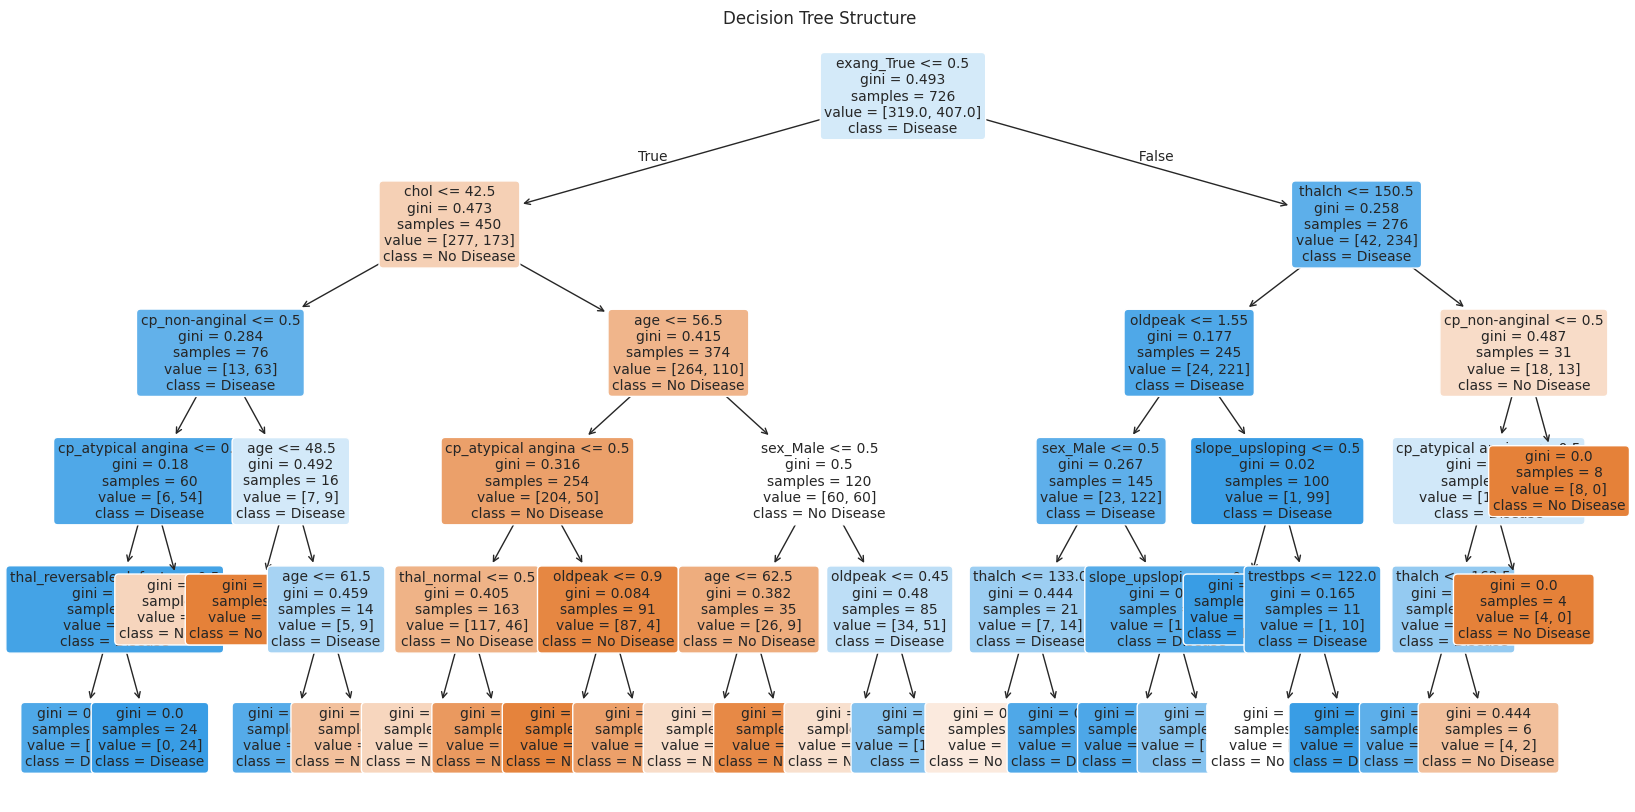

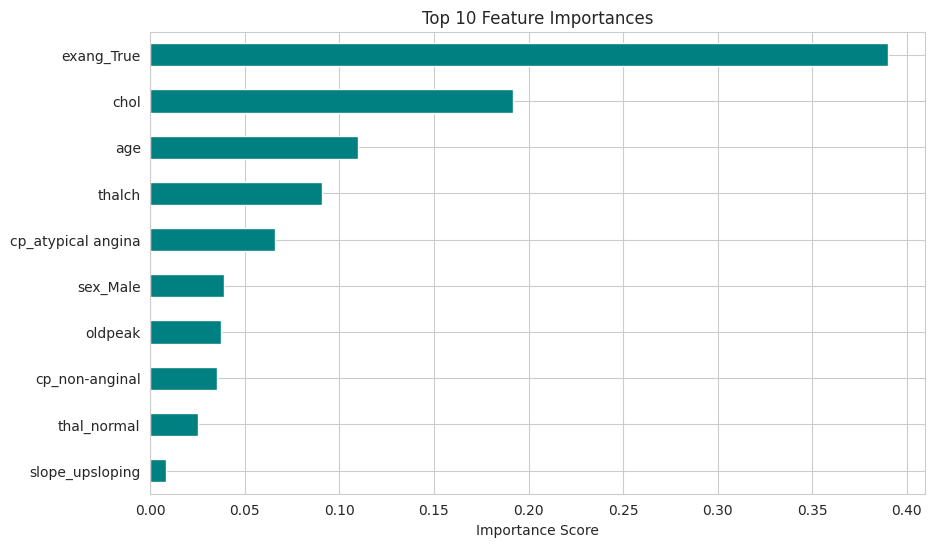

In [53]:
from sklearn.tree import plot_tree

# Plot Tree Structure
plt.figure(figsize=(20, 10))
plot_tree(
    best_tree,
    feature_names=X_encoded.columns,
    class_names=["No Disease", "Disease"],
    filled=True,
    rounded=True,
    fontsize=10,
)
plt.title("Decision Tree Structure")
plt.show()

# Plot Top 10 Feature Importances
importances = pd.Series(
    best_tree.feature_importances_, index=X_encoded.columns
).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
importances.head(10).plot(kind="barh", color="teal")
plt.title("Top 10 Feature Importances")
plt.xlabel("Importance Score")
plt.gca().invert_yaxis()
plt.show()

## Interview Questions


1. What are common hyperparameters of decision tree models, and how do they affect performance?

max_depth: Controls the maximum depth of the tree. Higher values increase model complexity and risk overfitting, while lower values restrict depth to prevent overfitting (though setting it too low can cause underfitting).

min_samples_split: The minimum number of samples required to split an internal node. Larger values prevent the model from learning overly specific noise patterns in tiny subsets.

min_samples_leaf: The minimum number of samples required at a leaf node. Higher values smooth the decision boundary and reduce variance.

criterion: The function measuring split quality (gini for Gini Impurity or entropy for Information Gain).

2. What is the difference between Label Encoding and One-Hot Encoding?

In [55]:


print(
    f"{'Feature':<22} | {'Label Encoding':<50} | {'One-Hot Encoding':<50}"
)
print("-" * 128)
print(
    f"{'Mechanism':<22} | {'Assigns integer values (0, 1, 2...)':<50} | {'Creates binary columns (0 or 1)':<50}"
)
print(
    f"{'Ordinal Relationship':<22} | {'Implies order (0 < 1 < 2)':<50} | {'No order (treats as independent)':<50}"
)
print(
    f"{'Best Used For':<22} | {'Ordinal features (Low, Med, High)':<50} | {'Nominal features (Gender, Color)':<50}"
)
print(
    f"{'Dimensionality Impact':<22} | {'Same feature count (1 column)':<50} | {'Increases columns (N new columns)':<50}"
)

Feature                | Label Encoding                                     | One-Hot Encoding                                  
--------------------------------------------------------------------------------------------------------------------------------
Mechanism              | Assigns integer values (0, 1, 2...)                | Creates binary columns (0 or 1)                   
Ordinal Relationship   | Implies order (0 < 1 < 2)                          | No order (treats as independent)                  
Best Used For          | Ordinal features (Low, Med, High)                  | Nominal features (Gender, Color)                  
Dimensionality Impact  | Same feature count (1 column)                      | Increases columns (N new columns)                 
